In [83]:
# Basic
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Model Selection
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb

# Metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Save Model
import joblib

sns.set(style="whitegrid")

In [84]:
df = pd.read_csv("merged_crop_dataset.csv")  # adjust path if needed

df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,24,128,196,22.750888,90.694892,5.521467,110.431786,apple
1,7,144,197,23.849401,94.348150,6.133221,114.051249,apple
2,14,128,205,22.608010,94.589006,6.226290,116.039659,apple
3,8,120,201,21.186674,91.134357,6.321152,122.233323,apple
4,20,129,201,23.410447,91.699133,5.587906,116.077793,apple


In [86]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6596 entries, 0 to 6595
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            6596 non-null   int64  
 1   P            6596 non-null   int64  
 2   K            6596 non-null   int64  
 3   temperature  6596 non-null   float64
 4   humidity     6596 non-null   float64
 5   ph           6596 non-null   float64
 6   rainfall     6596 non-null   float64
 7   label        6596 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 412.4+ KB
None
                 N            P            K  temperature     humidity  \
count  6596.000000  6596.000000  6596.000000  6596.000000  6596.000000   
mean     65.334900    48.164494    50.290024    25.397240    73.407185   
std      45.431015    23.699351    39.812887     5.052873    17.588425   
min       0.000000     5.000000     5.000000     1.180000    14.258040   
25%      26.000000    35.000000    

In [90]:
df['label'] = df['label'].str.strip()

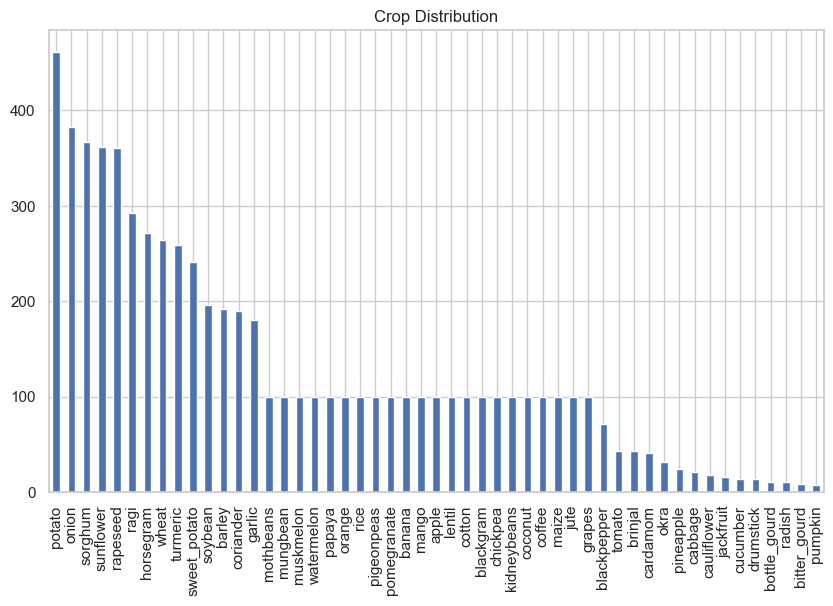

In [91]:
plt.figure(figsize=(10,6))
df['label'].value_counts().plot(kind='bar')
plt.title("Crop Distribution")
plt.show()

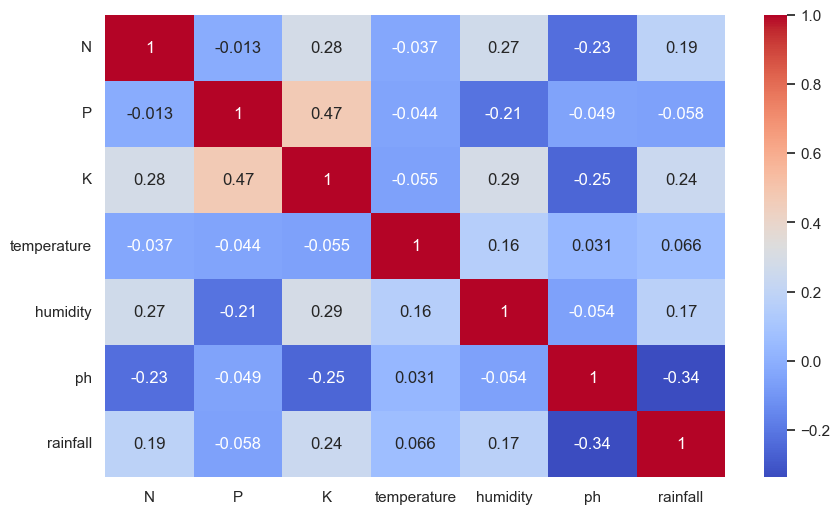

In [92]:
plt.figure(figsize=(10,6))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

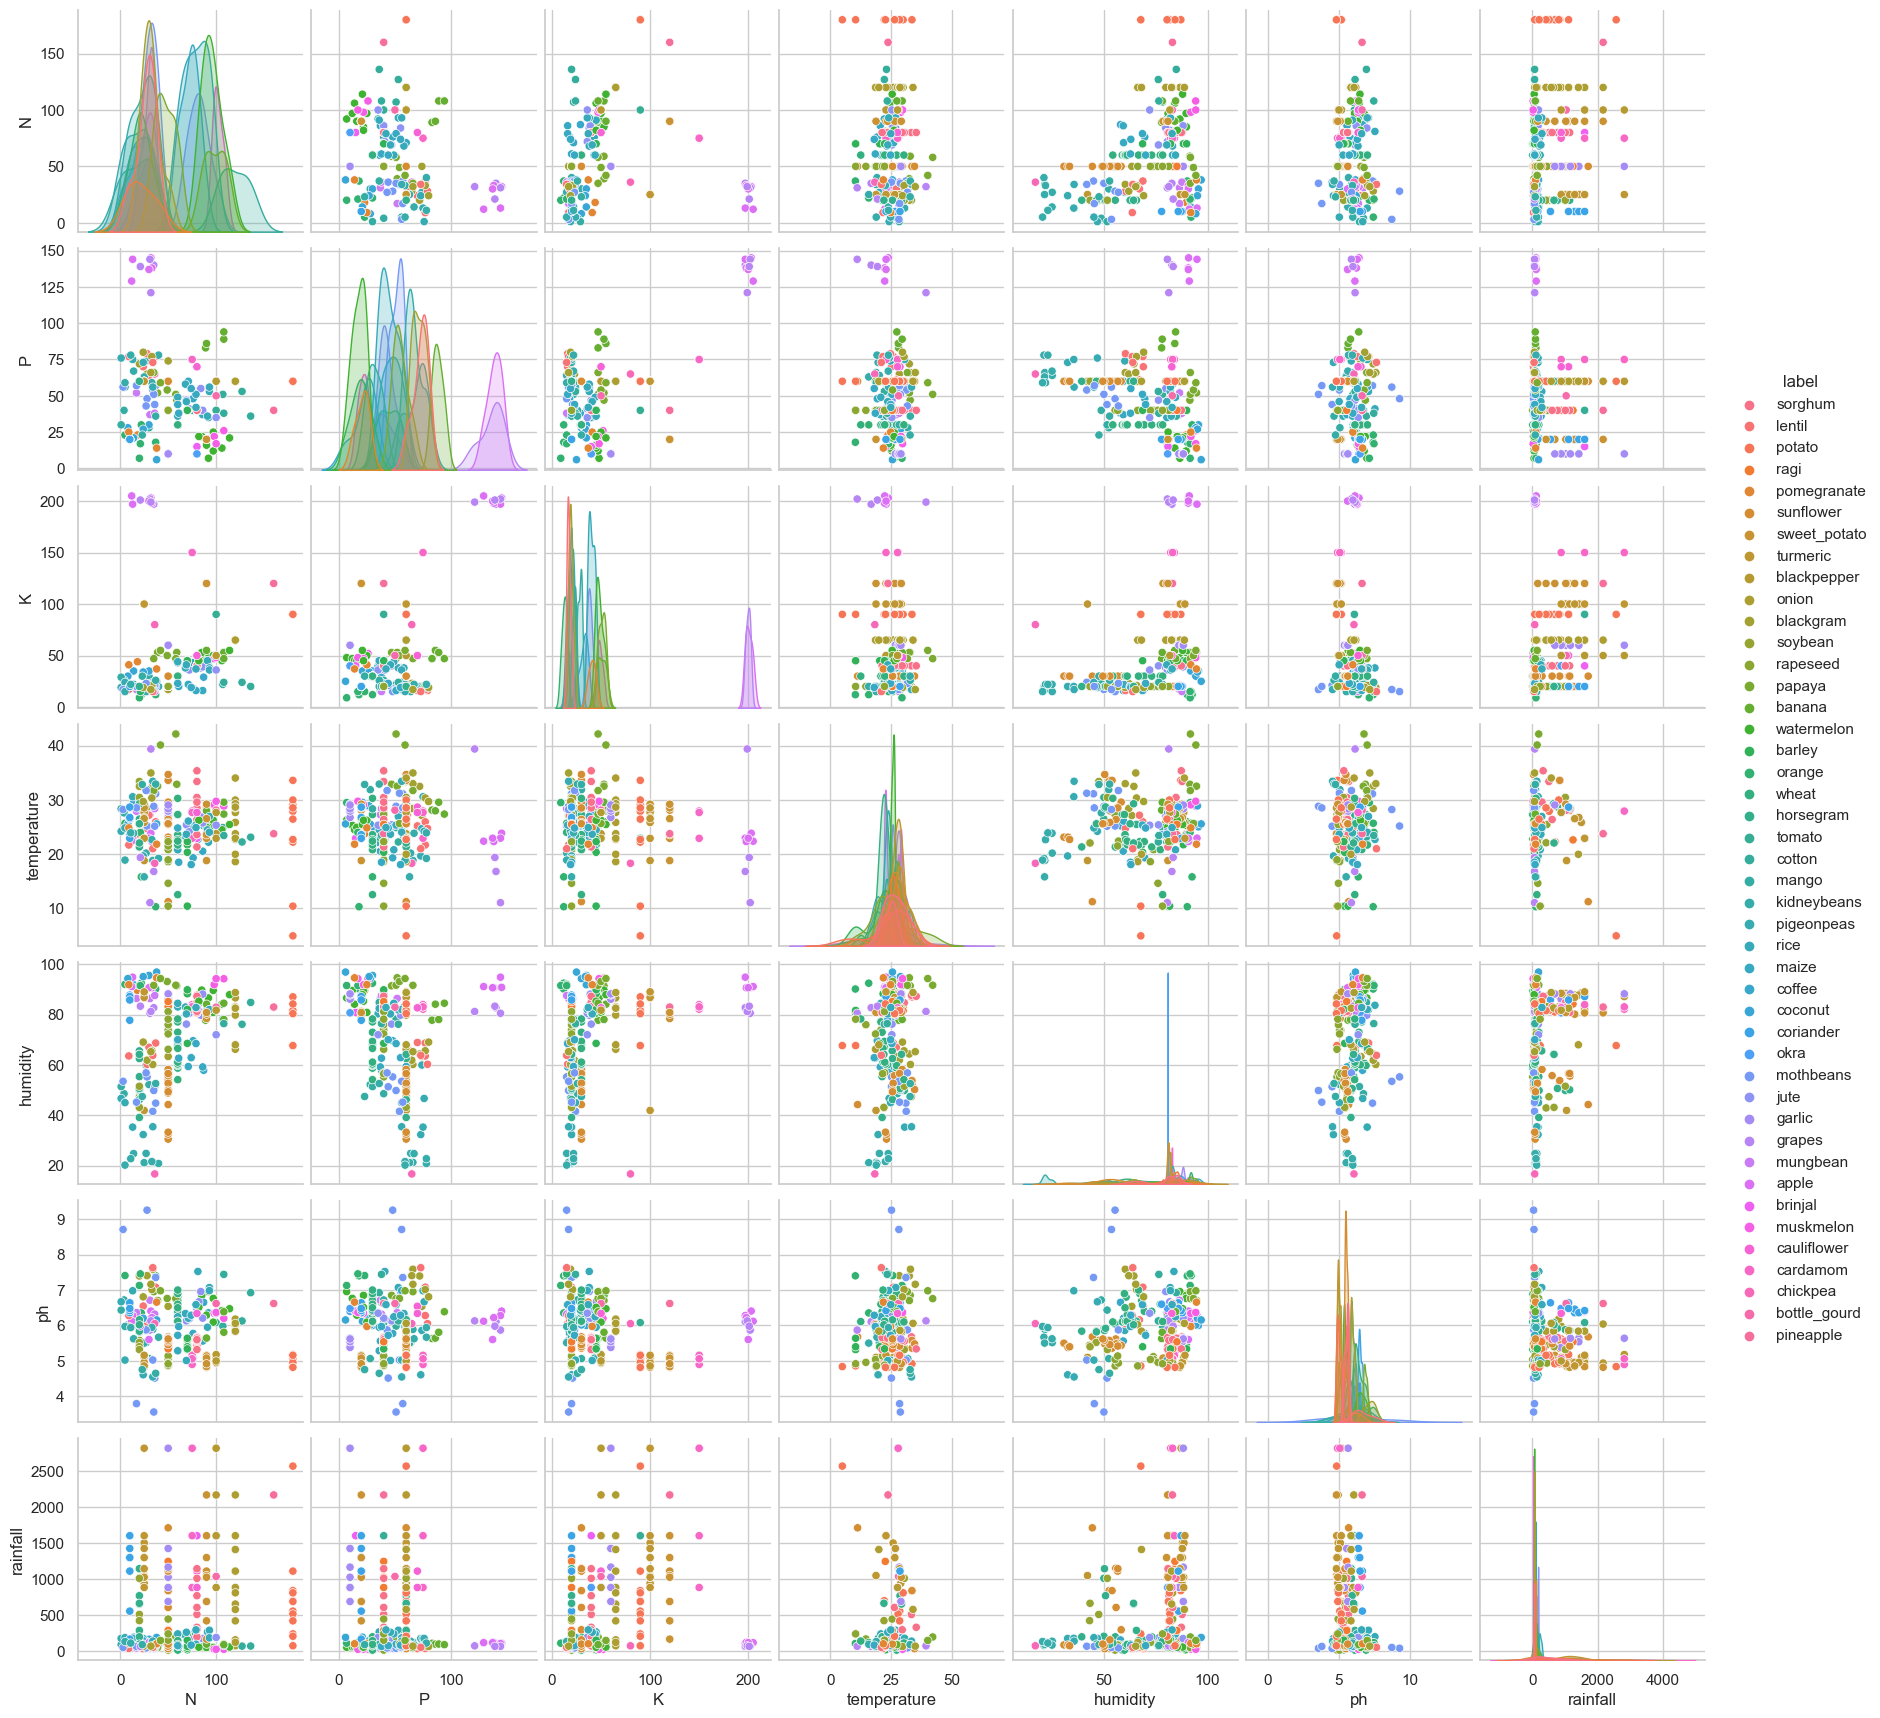

In [93]:
sns.pairplot(df.sample(300), hue='label')  # sample for speed
plt.show()

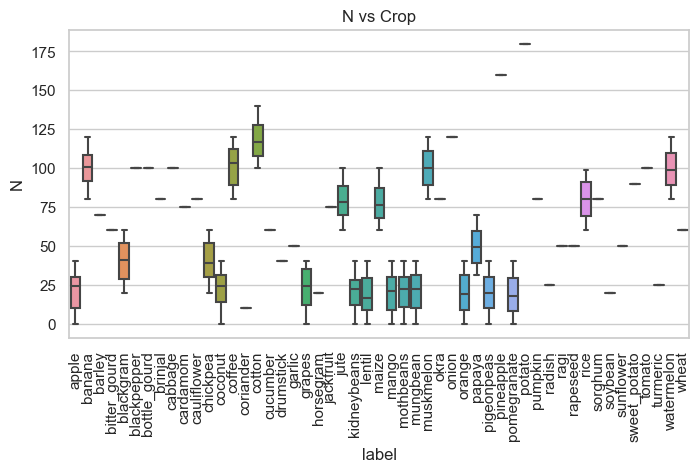

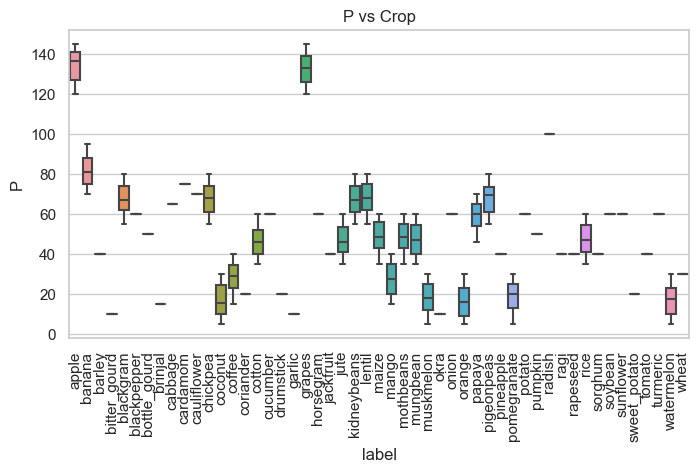

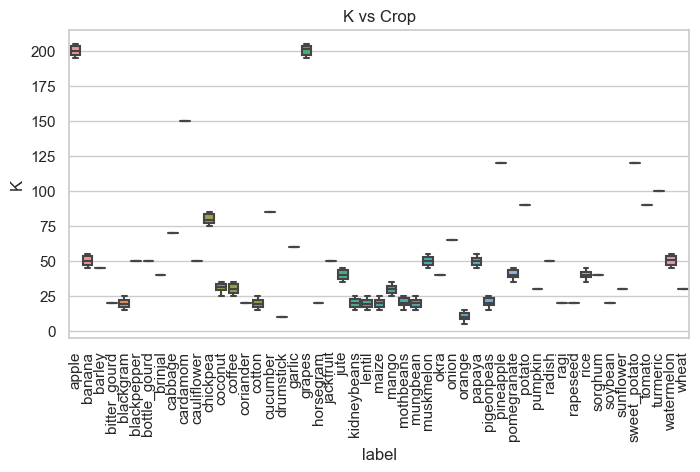

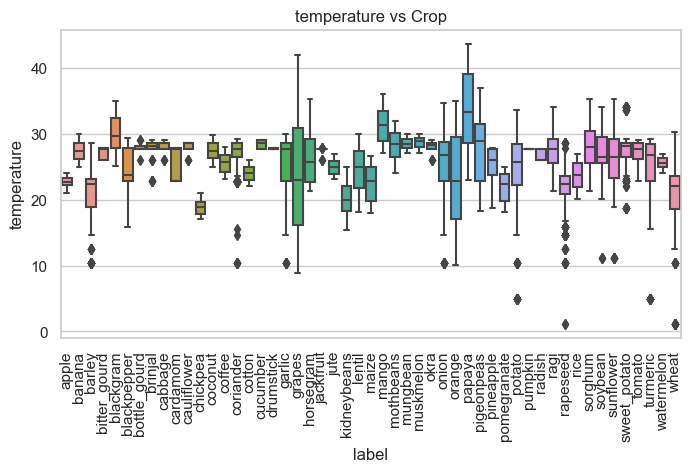

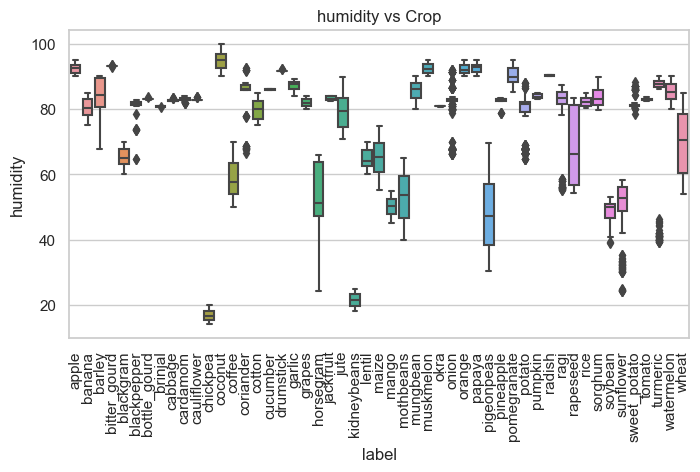

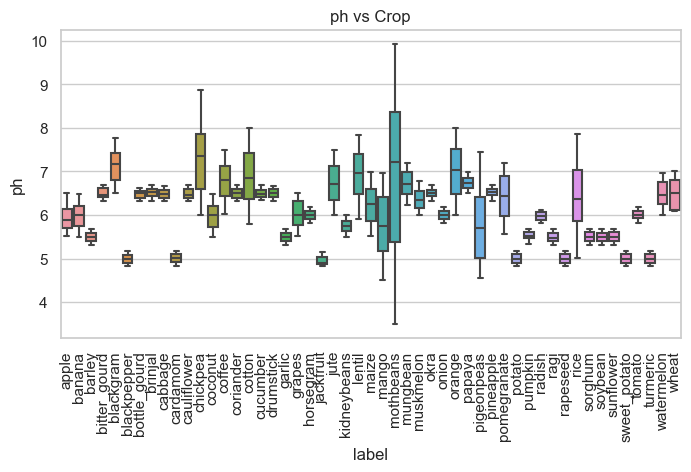

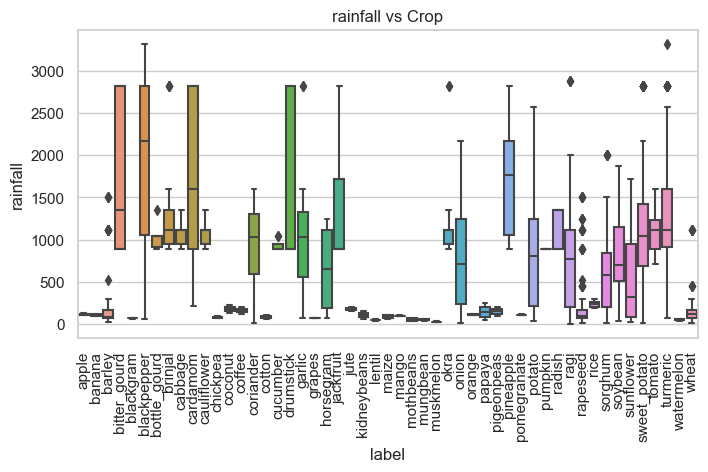

In [94]:
features = ['N','P','K','temperature','humidity','ph','rainfall']

for col in features:
    plt.figure(figsize=(8,4))
    sns.boxplot(x='label', y=col, data=df)
    plt.xticks(rotation=90)
    plt.title(f"{col} vs Crop")
    plt.show()

In [95]:
X = df.drop('label', axis=1)
y = df['label']

# Split FIRST (important)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Encode target
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

# Scale AFTER split
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [96]:
models = {
    "Logistic": LogisticRegression(max_iter=500),
    "DecisionTree": DecisionTreeClassifier(),
    "RandomForest": RandomForestClassifier(),
    "GradientBoost": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier(),
    "NaiveBayes": GaussianNB(),
    "XGBoost": xgb.XGBClassifier(eval_metric='mlogloss')
}

In [97]:
results = {}
best_model = None
best_score = 0

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"\n{name}")
    print("="*30)
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))

    if acc > best_score:
        best_score = acc
        best_model = model


Logistic
Accuracy: 0.9287878787878788
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       0.84      0.95      0.89        38
           3       0.00      0.00      0.00         2
           4       0.83      1.00      0.91        20
           5       1.00      0.93      0.96        14
           6       0.00      0.00      0.00         2
           7       0.73      0.89      0.80         9
           8       1.00      0.50      0.67         4
           9       1.00      1.00      1.00         8
          10       1.00      1.00      1.00         4
          11       1.00      1.00      1.00        20
          12       1.00      1.00      1.00        20
          13       1.00      1.00      1.00        20
          14       1.00      0.95      0.97        38
          15       1.00      0.95      0.97        20
          16       1.00      1.00      1.0

C:\Users\ghans\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.7_qbz5n2kfra8p0\LocalCache\local-packages\Python37\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\ghans\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.7_qbz5n2kfra8p0\LocalCache\local-packages\Python37\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\ghans\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.7_qbz5n2kfra8p0\LocalCache\local-packages\Python37\site-packages\sklearn\metrics\_classification.py:1318: Unde


RandomForest
Accuracy: 0.996969696969697
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      1.00      1.00        38
           3       1.00      1.00      1.00         2
           4       1.00      0.95      0.97        20
           5       1.00      1.00      1.00        14
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         9
           8       1.00      1.00      1.00         4
           9       1.00      1.00      1.00         8
          10       1.00      1.00      1.00         4
          11       1.00      1.00      1.00        20
          12       1.00      1.00      1.00        20
          13       1.00      1.00      1.00        20
          14       1.00      1.00      1.00        38
          15       1.00      1.00      1.00        20
          16       1.00      1.00      

C:\Users\ghans\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.7_qbz5n2kfra8p0\LocalCache\local-packages\Python37\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\ghans\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.7_qbz5n2kfra8p0\LocalCache\local-packages\Python37\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\ghans\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.7_qbz5n2kfra8p0\LocalCache\local-packages\Python37\site-packages\sklearn\metrics\_classification.py:1318: Unde

In [98]:
print("Best Model:", best_model)
print("Best Accuracy:", best_score)

Best Model: RandomForestClassifier()
Best Accuracy: 0.996969696969697


In [100]:
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5)
    print(f"{name}: {scores.mean():.4f}")

Logistic: 0.9246
DecisionTree: 0.9846
RandomForest: 0.9985
GradientBoost: 0.9941
KNN: 0.9519
NaiveBayes: 0.9962
XGBoost: 0.9949


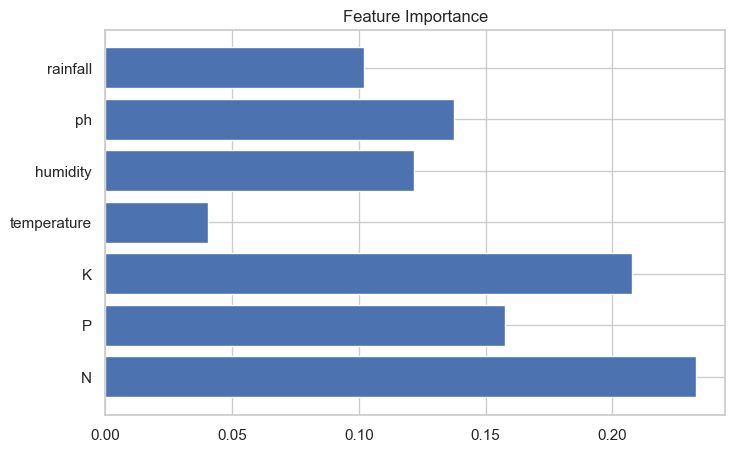

In [101]:
if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_

    plt.figure(figsize=(8,5))
    plt.barh(features, importances)
    plt.title("Feature Importance")
    plt.show()

In [102]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

best_model = grid.best_estimator_

Best Params: {'max_depth': None, 'n_estimators': 200}


In [105]:
joblib.dump(best_model, "./models/crop_model.pkl")
joblib.dump(scaler, "./models/scaler.pkl")
joblib.dump(le, "./models/label_encoder.pkl")

['./models/label_encoder.pkl']

In [109]:
def predict_top_k(model, scaler, le, sample, k=3):
    # Scale input
    sample_scaled = scaler.transform(sample)
    
    # Get probabilities
    probs = model.predict_proba(sample_scaled)[0]
    
    # Get top k indices
    top_k_idx = probs.argsort()[-k:][::-1]
    
    # Convert to labels
    top_crops = le.inverse_transform(top_k_idx)
    top_probs = probs[top_k_idx]
    
    return list(zip(top_crops, top_probs))

In [110]:
sample = [[90, 40, 40, 25, 80, 6.5, 200]]

top_3 = predict_top_k(best_model, scaler, le, sample, k=3)

print("Top 3 Recommended Crops:\n")

for i, (crop, prob) in enumerate(top_3, 1):
    print(f"{i}. {crop} → {prob*100:.2f}% confidence")

Top 3 Recommended Crops:

1. rice → 60.50% confidence
2. jute → 36.50% confidence
3. sorghum → 2.50% confidence


C:\Users\ghans\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.7_qbz5n2kfra8p0\LocalCache\local-packages\Python37\site-packages\sklearn\base.py:451: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  "X does not have valid feature names, but"


In [111]:
print(hasattr(best_model, "predict_proba"))

True
